# 02 - MTOW Iteration

The Maximum Takeoff Weight (MTOW) cannot be determined directly because many mass components depend on MTOW itself. This creates a **circular dependency**:

```
MTOW  ──▶  Structural Mass  ──▶  Drag  ──▶  Power  ──▶  Energy  ──▶  Battery Mass  ──┐
  ▲                                                                                     │
  │                                                                                     │
  │                                                                                     │
  └──────────  MTOW_new = Empty Mass + Battery Mass + Payload  ◀────────────────────────┘
```

`evtolpy` handles this by using **fixed-point iteration**:

1. Start with an initial MTOW guess (from the JSON file)
2. Compute energy requirements, battery mass, structural masses, and empty weight
3. Sum empty weight + battery + payload to get a new MTOW estimate
4. Repeat until $|MTOW_{new} - MTOW_{old}| < 0.001$ kg


In [22]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft

aircraft = Aircraft('../Archer_Midnight.json')

## Running the Iteration

The `_iterate_mtow()` method returns the final converged MTOW and a history list showing each iteration.

In [23]:
final_mtow, history = aircraft._iterate_mtow()

print(f"Initial MTOW guess: {history[0]['mtow_guess_kg']:.2f} kg")
print(f"Converged MTOW:     {final_mtow:.2f} kg")
print(f"Iterations:         {len(history)}")

Initial MTOW guess: 3175.00 kg
Converged MTOW:     3193.36 kg
Iterations:         23


## Iteration History Table

In [24]:
print(f"{'Iter':>4s} {'Guess (kg)':>12s} {'New (kg)':>12s} {'Delta (kg)':>12s} {'Empty (kg)':>12s} {'Batt (kg)':>10s}")
print("-" * 65)
for row in history:
    print(f"{row['iteration']:>4d} {row['mtow_guess_kg']:>12.2f} {row['new_mtow_kg']:>12.2f} "
          f"{row['delta_kg']:>12.4f} {row['empty_mass_kg']:>12.2f} {row['battery_mass_kg']:>10.2f}")

Iter   Guess (kg)     New (kg)   Delta (kg)   Empty (kg)  Batt (kg)
-----------------------------------------------------------------
   0      3175.00      3181.02       6.0187      1758.99     969.03
   1      3181.02      3185.06       4.0426      1761.21     970.85
   2      3185.06      3187.78       2.7173      1762.71     972.07
   3      3187.78      3189.61       1.8274      1763.71     972.89
   4      3189.61      3190.84       1.2294      1764.39     973.45
   5      3190.84      3191.66       0.8272      1764.84     973.82
   6      3191.66      3192.22       0.5567      1765.15     974.07
   7      3192.22      3192.59       0.3747      1765.36     974.24
   8      3192.59      3192.85       0.2522      1765.49     974.35
   9      3192.85      3193.02       0.1698      1765.59     974.43
  10      3193.02      3193.13       0.1143      1765.65     974.48
  11      3193.13      3193.21       0.0769      1765.69     974.51
  12      3193.21      3193.26       0.0518      1

## Visualize Convergence

The left plot shows MTOW converging from the initial guess to the final value. The right plot uses a log scale to show the exponential convergence rate, each iteration reduces the error.

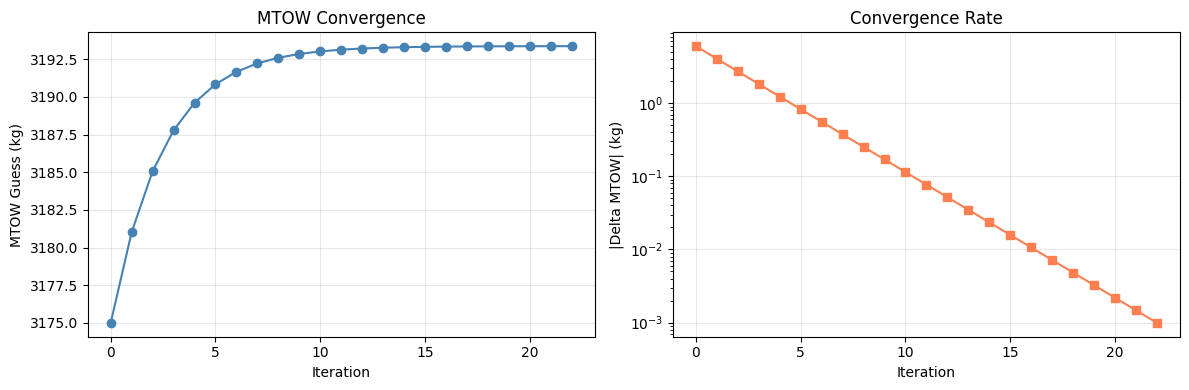

In [25]:
import matplotlib.pyplot as plt

iters = [row['iteration'] for row in history]
mtow_guesses = [row['mtow_guess_kg'] for row in history]
deltas = [abs(row['delta_kg']) for row in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(iters, mtow_guesses, 'o-', color='steelblue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('MTOW Guess (kg)')
ax1.set_title('MTOW Convergence')
ax1.grid(True, alpha=0.3)

ax2.semilogy(iters, deltas, 's-', color='coral')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('|Delta MTOW| (kg)')
ax2.set_title('Convergence Rate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

The MTOW iteration process couples:

- **Hover power** depends on MTOW through thrust requirement: $T = m \cdot g$, and induced velocity: $v_i = \sqrt{T/(2\rho A)}$
- **Cruise power** depends on MTOW through wing area (stall speed constraint) and drag
- **Energy requirements** sums power across all segments, driving battery mass
- **Battery mass** directly adds to MTOW
- **Structural mass** scales with MTOW through parametric equations

This coupling creates a **snowball effect** where any mass increase in one component cascades through the system. A 1 kg increase in payload requires more than 1 kg of additional MTOW because it requires more battery energy, which requires more battery mass, which requires more structural mass, and so on.

**Next:** Move on to [05 - Power and Energy Analysis]to examine per segment power and energy.